## P14_P19

In [1]:
import json, math, re
from pathlib import Path

import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.models.resnet import ResNet, BasicBlock

RUNS = Path("/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/aug_17_run")                       # <-- output dir of train_depth_sweep.py
DATA = Path("/home/stephen/imagenet")     # <-- edit
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_DEPTHS = {"plain8": 8, "plain14": 14, "plain20": 20, "plain26": 26,
                "plain34": 34, "plain56": 56, "plain74": 74, "resnet74": 74}
MODELS = [m for m in MODEL_DEPTHS if (RUNS / m).exists()]

def color_of(name):
    """Plain nets: dark->light with depth. ResNet: red."""
    if name == "resnet74":
        return "crimson"
    depths = sorted(d for m, d in MODEL_DEPTHS.items() if m != "resnet74")
    return plt.cm.viridis(depths.index(MODEL_DEPTHS[name]) / (len(depths) - 1))

print(torch.__version__, device, "| runs found:", MODELS)

2.12.1+cu130 cuda | runs found: ['plain8', 'plain14', 'plain20', 'plain26', 'plain34', 'plain56', 'plain74', 'resnet74']


In [2]:
# --- model definitions (mirrors train_depth_sweep.py) ---
class PlainBasicBlock(BasicBlock):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.downsample = None

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        return out

LAYER_CFG = {8: [1,1,1,1], 14: [2,1,1,2], 20: [2,2,3,2], 26: [3,3,3,3],
             34: [4,4,4,4], 56: [3,4,17,3], 74: [3,4,26,3]}

def make_net(depth_target, use_skip, num_classes=1000):
    block = BasicBlock if use_skip else PlainBasicBlock
    model = ResNet(block, LAYER_CFG[depth_target], num_classes=num_classes)
    if depth_target == 8:
        model.layer4 = nn.Identity()
        model.fc = nn.Linear(256, num_classes)
    return model

def blocks_of(model):
    return [b for s in (model.layer1, model.layer2, model.layer3, model.layer4)
            if isinstance(s, nn.Sequential) for b in s]

In [3]:
# --- metrics loading: prefer metrics.npz, fall back to metrics.jsonl ---
def load_metrics(name):
    d = RUNS / name
    if (d / "metrics.npz").exists():
        return dict(np.load(d / "metrics.npz"))
    recs = [json.loads(l) for l in open(d / "metrics.jsonl") if l.strip()]
    out = {}
    for k in recs[0]:
        if k in ("block_grad_norms", "block_acts"):
            continue
        out[k] = np.array([r.get(k, np.nan) for r in recs], dtype=np.float64)
    out["block_grad_norms"] = np.array([r["block_grad_norms"] for r in recs])
    return out

M = {name: load_metrics(name) for name in MODELS}
for name in MODELS:
    print(f"{name:9s} records={len(M[name]['step']):5d} "
          f"last step={int(M[name]['step'][-1])}")

plain8    records=  400 last step=40000
plain14   records=  500 last step=50000
plain20   records=  600 last step=60000
plain26   records=  700 last step=70000
plain34   records=  800 last step=80000
plain56   records=  900 last step=90000
plain74   records= 1000 last step=100000
resnet74  records= 1100 last step=110000


In [4]:
def list_ckpts(name):
    return sorted(int(re.search(r"(\d+)", p.stem).group(1))
                  for p in (RUNS / name).glob("ckpt_step*.pt"))

def load_model(name, step=None):
    d = RUNS / name
    path = d / "final.pt" if step is None else d / f"ckpt_step{step:06d}.pt"
    model = make_net(MODEL_DEPTHS[name], use_skip=name.startswith("resnet"))
    model.load_state_dict(torch.load(path, map_location=device))
    return model.to(device).eval()

print("plain74 checkpoints:", list_ckpts("plain74")[:5], "...",
      list_ckpts("plain74")[-2:])

plain74 checkpoints: [1000, 2000, 3000, 4000, 5000] ... [99000, 100000]


In [5]:
# --- validation data (same transforms as training script) ---
import torchvision.datasets as dsets, torchvision.transforms as T

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
val_ds = dsets.ImageFolder(DATA / "ILSVRC/Data/CLS-LOC/val",
    T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor(),
               T.Normalize(MEAN, STD)]))
val_loader = torch.utils.data.DataLoader(val_ds, 64, shuffle=True,
    num_workers=4, pin_memory=True)

# wnid -> human-readable name (Kaggle CLS-LOC ships this mapping)
wnid_words = {}
mapping = DATA / "LOC_synset_mapping.txt"
if mapping.exists():
    for line in open(mapping):
        wnid, words = line.strip().split(" ", 1)
        wnid_words[wnid] = words.split(",")[0]

def class_name(idx):
    if 0 <= idx < len(val_ds.classes):
        wnid = val_ds.classes[idx]
        return wnid_words.get(wnid, wnid)
    return f"cls{idx}"

def denorm(x):  # CHW tensor -> HWC numpy in [0,1] for imshow
    img = x.cpu() * torch.tensor(STD).view(3,1,1) + torch.tensor(MEAN).view(3,1,1)
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

print(len(val_ds), "val images,", len(val_ds.classes), "classes")

50000 val images, 1000 classes


In [6]:
# --- forward + backward on a batch of val images ---
name = "plain74" if "plain74" in MODELS else MODELS[-1]
model = load_model(name)

x, y = next(iter(val_loader))
x, y = x[:16].to(device), y[:16].to(device)

logits = model(x)
loss = F.cross_entropy(logits, y)
model.zero_grad(set_to_none=True)
loss.backward()

probs = logits.softmax(1)
top5p, top5i = probs.topk(5, dim=1)
print(f"{name}: batch loss={loss.item():.3f}, "
      f"batch top-1={(logits.argmax(1) == y).float().mean().item():.3f}\n")
for i in range(3):
    guesses = ", ".join(f"{class_name(top5i[i,j].item())} {top5p[i,j]:.2f}"
                        for j in range(5))
    print(f"true: {class_name(y[i].item()):22s} -> {guesses}")

plain74: batch loss=2.434, batch top-1=0.188

true: washer                 -> car wheel 0.16, disk brake 0.12, barbell 0.09, coil 0.08, washer 0.05
true: Cardigan               -> papillon 0.31, Pembroke 0.21, Cardigan 0.13, Siamese cat 0.07, Chihuahua 0.06
true: grand piano            -> grand piano 0.97, upright 0.01, marimba 0.01, organ 0.00, crane 0.00


## Intermediate Activations

plain14: cached 42 activations, 0.20 GB for batch of 8

conv1                (8, 64, 112, 112)
bn1                  (8, 64, 112, 112)
relu                 (8, 64, 112, 112)
maxpool              (8, 64, 56, 56)
layer1.0.conv1       (8, 64, 56, 56)
layer1.0.bn1         (8, 64, 56, 56)
...


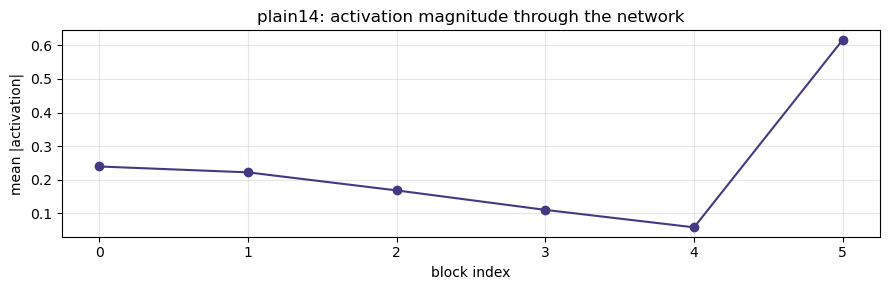

In [7]:
# --- cache all intermediate activations through a model ---
class ActivationCache:
    """with ActivationCache(model) as cache: model(x)  ->  cache["layer3.5.bn2"]
    Hooks every leaf module (+ the residual blocks and stages themselves),
    stores detached outputs keyed by qualified module name, in forward order."""
    def __init__(self, model, to_cpu=True, leaf_only=False):
        self.model, self.to_cpu, self.leaf_only = model, to_cpu, leaf_only
        self.cache, self.handles = {}, []

    def _keep(self, name, mod):
        if name == "":                      # the model itself
            return False
        if self.leaf_only:
            return len(list(mod.children())) == 0
        return not isinstance(mod, (nn.Sequential, nn.Identity))

    def __enter__(self):
        def hook(name):
            def fn(mod, inp, out):
                if torch.is_tensor(out):
                    self.cache[name] = out.detach().cpu() if self.to_cpu else out.detach()
            return fn
        for name, mod in self.model.named_modules():
            if self._keep(name, mod):
                self.handles.append(mod.register_forward_hook(hook(name)))
        return self.cache

    def __exit__(self, *a):
        for h in self.handles:
            h.remove()
        self.handles.clear()

# name = "plain74" if "plain74" in MODELS else MODELS[-1]
name = "plain14"
model = load_model(name)
x, y = next(iter(val_loader))
x = x[:8].to(device)

with ActivationCache(model) as cache:
    with torch.no_grad():
        model(x)

total = sum(v.numel() * v.element_size() for v in cache.values()) / 1e9
print(f"{name}: cached {len(cache)} activations, {total:.2f} GB "
      f"for batch of {x.shape[0]}\n")
for k in list(cache)[:6]:
    print(f"{k:20s} {tuple(cache[k].shape)}")
print("...")
# e.g. mean |activation| out of each residual block, through the net:
block_keys = [k for k in cache if k.count(".") == 1 and k.startswith("layer")]
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot([cache[k].abs().mean().item() for k in block_keys], "o-",
        color=color_of(name))
ax.set(xlabel="block index", ylabel="mean |activation|",
       title=f"{name}: activation magnitude through the network")
ax.grid(alpha=0.3); plt.tight_layout()

In [8]:
block_keys

['layer1.0', 'layer1.1', 'layer2.0', 'layer3.0', 'layer4.0', 'layer4.1']

In [9]:
cache.keys()

dict_keys(['conv1', 'bn1', 'relu', 'maxpool', 'layer1.0.conv1', 'layer1.0.bn1', 'layer1.0.relu', 'layer1.0.conv2', 'layer1.0.bn2', 'layer1.0', 'layer1.1.conv1', 'layer1.1.bn1', 'layer1.1.relu', 'layer1.1.conv2', 'layer1.1.bn2', 'layer1.1', 'layer2.0.conv1', 'layer2.0.bn1', 'layer2.0.relu', 'layer2.0.conv2', 'layer2.0.bn2', 'layer2.0', 'layer3.0.conv1', 'layer3.0.bn1', 'layer3.0.relu', 'layer3.0.conv2', 'layer3.0.bn2', 'layer3.0', 'layer4.0.conv1', 'layer4.0.bn1', 'layer4.0.relu', 'layer4.0.conv2', 'layer4.0.bn2', 'layer4.0', 'layer4.1.conv1', 'layer4.1.bn1', 'layer4.1.relu', 'layer4.1.conv2', 'layer4.1.bn2', 'layer4.1', 'avgpool', 'fc'])

In [10]:
for k, v in cache.items():
    print(k, v.shape)

conv1 torch.Size([8, 64, 112, 112])
bn1 torch.Size([8, 64, 112, 112])
relu torch.Size([8, 64, 112, 112])
maxpool torch.Size([8, 64, 56, 56])
layer1.0.conv1 torch.Size([8, 64, 56, 56])
layer1.0.bn1 torch.Size([8, 64, 56, 56])
layer1.0.relu torch.Size([8, 64, 56, 56])
layer1.0.conv2 torch.Size([8, 64, 56, 56])
layer1.0.bn2 torch.Size([8, 64, 56, 56])
layer1.0 torch.Size([8, 64, 56, 56])
layer1.1.conv1 torch.Size([8, 64, 56, 56])
layer1.1.bn1 torch.Size([8, 64, 56, 56])
layer1.1.relu torch.Size([8, 64, 56, 56])
layer1.1.conv2 torch.Size([8, 64, 56, 56])
layer1.1.bn2 torch.Size([8, 64, 56, 56])
layer1.1 torch.Size([8, 64, 56, 56])
layer2.0.conv1 torch.Size([8, 128, 28, 28])
layer2.0.bn1 torch.Size([8, 128, 28, 28])
layer2.0.relu torch.Size([8, 128, 28, 28])
layer2.0.conv2 torch.Size([8, 128, 28, 28])
layer2.0.bn2 torch.Size([8, 128, 28, 28])
layer2.0 torch.Size([8, 128, 28, 28])
layer3.0.conv1 torch.Size([8, 256, 14, 14])
layer3.0.bn1 torch.Size([8, 256, 14, 14])
layer3.0.relu torch.Size([

## P19 and 20
- Examples we're getting right/wrong
- One will be the Drum
- This is for ResNet-8

In [14]:
def load_image(idx):
    x, y = val_ds[idx]
    return x.unsqueeze(0).to(device), torch.tensor([y], device=device)

In [19]:
@torch.no_grad()
def correct_ans_conf(model, x, y):
    return torch.nn.Softmax()(model(x))[0, y.item()].item()

In [20]:
model=load_model('plain8')

In [38]:
save_dir = Path('/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/p19_samples')
save_dir.mkdir(parents=True, exist_ok=True)

In [40]:
rI = np.arange(50000)
np.random.shuffle(rI)

KeyboardInterrupt: 

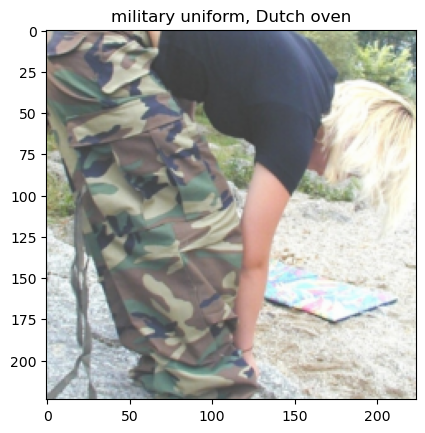

In [44]:
for img_idx in rI[:1000]:

    x, y = load_image(img_idx)
    cls = val_ds.classes[y.item()]
    # print(wnid_words[cls], correct_ans_conf(model, x, y))
    yhat_index=model(x).argmax().item()
    
    plt.imshow(denorm(x[0]))
    plt.title(wnid_words[cls] + ', ' + wnid_words[val_ds.classes[yhat_index]])
    plt.savefig(save_dir/(str(img_idx)+'.png'))

Nice correct examples
 - `47587` Lemon
 - `6538` Flamingo
 - `21299` Barn

Nice incorrect examples
- `38250` Rocking chair -> turnstyle
- `38552` safe -> rotisserie

In [48]:
img_idx=47587

x, y = load_image(img_idx)
cls = val_ds.classes[y.item()]
print(wnid_words[cls], correct_ans_conf(model, x, y))
yhat_index=model(x).argmax().item()

lemon 0.6079088449478149


In [47]:
yhat_index

951